- LLM Labeling：留言語意標註與模型驗證 - 

以 LLM 建立留言標註流程，將原始留言轉換為可分析之結構化資料，包含情緒（sentiment）、主題（focus topic）與語意重述（rewritten sentences）

完成標註後，透過人工標註驗證、分類指標及統計分析評估標註品質，
最後將 LLM 特徵導入觀看數模型，驗證文本資訊是否能提升額外解釋價值


In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/colabnotebooks/data_cleaning.csv",encoding='big5')
df.info()
df.shape
df.head()

**| data cleaning**

清理留言文字資料、統一格式與印出前十出現詞彙

In [ ]:
from collections import Counter
import re

df_exploded = df.assign(
    comment=df["comment_text"].str.split("/").apply(
        lambda x: [i.strip() for i in x if i.strip() != ""]
    )
).explode("comment")

def get_labels(text):
    return re.findall(r'\b\w+\b', str(text).lower())

all_words = []
for comment in df_exploded["comment"]:
    all_words.extend(get_labels(comment))

labels_counts = Counter(all_words)
top_10_labels = [word for word, count in labels_counts.most_common(10)]

print(labels_counts.most_common(10))
df_exploded.info()

[('0', 72), ('說真的', 19), ('1', 13), ('哇', 12), ('我愛你', 12), ('哈哈', 12), ('2', 11), ('彩妍', 9), ('3', 9), ('對吧', 8)]
<class 'pandas.core.frame.DataFrame'>
Index: 413 entries, 0 to 182
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   song          413 non-null    object 
 1   member        413 non-null    object 
 2   line_share    413 non-null    float64
 3   post_week     413 non-null    int64  
 4   opening       413 non-null    int64  
 5   ending_take   413 non-null    int64  
 6   center_count  413 non-null    int64  
 7   comment_text  413 non-null    object 
 8   views         413 non-null    int64  
 9   log_views     413 non-null    float64
 10  popularity    413 non-null    float64
 11  comment       413 non-null    object 
dtypes: float64(3), int64(5), object(4)
memory usage: 41.9+ KB


In [ ]:
top_10_labels = [word for word, count in labels_counts.most_common(10)]
for word in top_10_labels:
    print(word)

    mask = df_exploded["comment"].str.contains(rf'\b{word}\b', case=False, na=False)
    matched_texts = df_exploded[mask]["comment"].head(3)

    for i, text in enumerate(matched_texts, 1):
        clean_text = str(text).split(',')[0].strip()
        print(f"{i}. {clean_text}")

**| labeling process**

透過 Prompt Engineering 設計結構化提示詞，引導 LLM 將每則留言解析為固定格式，包含：

- Sentiment（情緒分數）
- Focus Topic（留言類別）
- Rewritten Sentence（語意重述）

Rewritten Sentence 將作為後續 Embedding、RAG 與 AI Agent 建立知識庫的核心文本

In [ ]:
import os
import re
import time
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from openai import OpenAI
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

from pydantic import BaseModel, Field
from typing import List, Literal

class SegmentedComment(BaseModel):
    rewritten_sentence_with_subject: str = Field(
        description="""請根據原始留言重建語意，輸出1至2句完整且具有邏輯的評論。
        規則如下：
        將長評論拆解後的獨立感官短句。若原文缺乏主詞，請結合上下文與成員名（如元英、恩妃、柔理等）自動補齊明確主詞（例如將『好美』補齊為『張元英的結尾姿勢好美』），長度請嚴格限制在 90 字內。

        若出現轉折詞或語意強調結構，例如：
        - 雖然...但...
        - 可是...
        - 不過...
        - 然而...
        - 反而...
        - 明明...
        - 結果...
        - 竟然...
        請優先保留轉折後所表達的主要觀點。必要時可重新組織句子，而非逐字複製。

        若出現問句、感嘆句或反問句，例如：
        - ?....
        - 為什麼...
        - 怎麼會...
        - 難道...
        - 真的嗎...
        請擷取其後真正表達評價的內容，而非單純保留疑問語句。

        請正確理解中文雙重否定，例如：不可能不愛，應依實際語意判讀，不可只依單一否定詞判斷情緒。

        若一個留言同時包含兩個以上的重要觀點，可輸出最多2句。也可以利用並且、以及、同時等連接詞整合語意。

        最終輸出應為為1-2個句子，長度限制在90字以內，並保留與舞台表現、唱功、顏值、鏡頭表現相關的重要資訊。避免刪除具有分析價值的重要內容。"""
    )
    focus_topic:Literal["visual","performance","vocal","identity","viral","other"] = Field(
        description="""這句評論核心討論的舞台曝光特徵類別,同時依照下列定義分類。若留言同時涉及多個主題，請選擇最主要、最核心的討論重點，只能輸出一個 focus_topic
        visual：討論顏值、造型、服裝、美貌、形容長相、小動物、皮膚。
        performance：討論舞蹈、Ending、Center、鏡頭、表現力、概念、才藝。
        vocal：討論歌唱實力、高音、音色。
        identity：討論成員本人、性格、身材、作品。
        viral：討論爆紅、人氣、觀看次數、流量、演算法。
        other：以上皆不符合。"""
    )
    sentiment_score: int = Field(
        description="該句的情感極性分數：2(強烈正面稱讚), 1(正面稱讚), 0(中立描述), -1(負面批評), -2(強烈負面批評)",
    )

class IdolCommentAnalysisResult(BaseModel):
    segmented_sentences: List[SegmentedComment]

try:
    from google.colab import userdata
    api_key = userdata.get("OPENAI_API_KEY").strip()
except Exception:
    api_key = os.environ.get("OPENAI_API_KEY").strip()

client = OpenAI(api_key=api_key)
TEXT_MODEL = "gpt-4.1-mini"
EMBEDDING_MODEL = "text-embedding-3-small"

def analyze_comment_via_llm(comment_text):
    system_prompt = (
        "你是一個精通 K-pop 追星文化與社群輿情的量化分析專家。\n"
        "你的任務是深挖直拍影片底下的觀眾評論，利用上下文語意回溯，將長篇評論拆解為具備『明確主詞與邏輯』的獨立感官句子。重建留言真正想表達的語意而非摘要。\n"
        "必須嚴格依據定義的 JSON 格式輸出，不得夾帶任何多餘的解釋文字。\n"
        "若出現轉折詞（雖然、但是、不過、然而等），優先保留轉折後的重要觀點。\n"
        "若出現問句、反問句或感嘆句，請擷取其中真正表達評價的內容。\n"
        "若存在雙重否定，請依整體語意判讀，而非逐字翻譯。\n"
        "若留言同時包含多個觀點，可保留最多兩句。\n"
    )
    try:
        completion = client.beta.chat.completions.parse(
            model=TEXT_MODEL,
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": f"原始影片留言如下：\n{comment_text}"}
            ],
            response_format=IdolCommentAnalysisResult,
            temperature=0.1
        )
        return completion.choices[0].message.parsed
    except Exception as e:
      print(e)
      return None

In [ ]:
sentiments = []
topics = []
rewritten_sentences = []

for i, comment in enumerate(df_exploded["comment"], 1):
  # 留言空值變NA
  if pd.isna(comment) or str(comment).strip() in ["", "0"]:
        sentiments.append(np.nan)
        topics.append(np.nan)
        rewritten_sentences.append(np.nan) # 對改寫後的句子也賦予 NaN，保持長度一致
  else:
        result = analyze_comment_via_llm(comment)
        if result and result.segmented_sentences:
            seg = result.segmented_sentences[0]
            sentiments.append(seg.sentiment_score)
            topics.append(seg.focus_topic)
            rewritten_sentences.append(seg.rewritten_sentence_with_subject)
        else:
            sentiments.append(0)
            topics.append("other")
            rewritten_sentences.append(comment)

In [ ]:
df_llm = df_exploded.copy()
df_llm["LLM_sentiment"] = sentiments
df_llm["focus_topic"] = topics
df_llm["rewritten_sentence"] = rewritten_sentences

**| 標註結果**

觀察各主題與情緒分布，確認資料是否具合理，並作為後續分析依據

In [ ]:
pd.crosstab(df_llm["member"],df_llm["focus_topic"])

focus_topic,identity,other,performance,viral,visual,vocal
member,,,,,,
chaewon,9,1,6,3,5,3
chaeyeon,5,1,21,0,6,0
eunbi,7,1,9,3,7,0
hitomi,11,0,6,0,11,1
hyewon,11,1,11,0,9,1
minju,11,1,3,0,10,1
nako,4,0,9,2,9,3
sakura,6,0,11,4,8,0
wonyoung,17,0,6,0,7,0


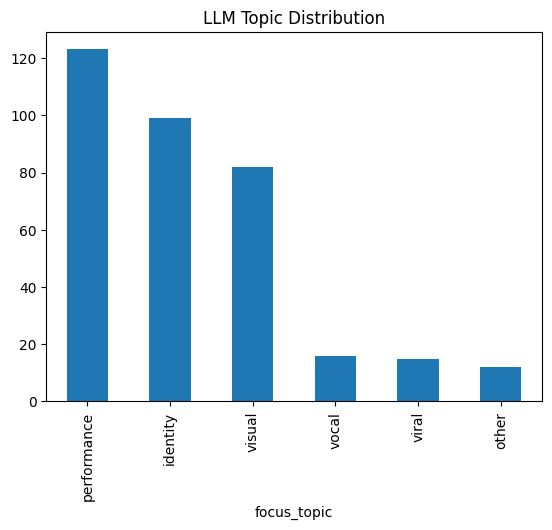

In [ ]:
topic_counts = (df_llm["focus_topic"].value_counts())
topic_counts.plot(kind="bar")
plt.title("LLM Topic Distribution")
plt.show()

In [ ]:
df_llm.groupby("focus_topic")["views"].mean().sort_values(ascending=False)

,views
focus_topic,
identity,841732.686869
other,761617.166667
viral,665676.000000
visual,625203.134146
performance,578295.609756
vocal,436793.750000


In [ ]:
df_llm.groupby("LLM_sentiment")["log_views"].mean()

,log_views
LLM_sentiment,
-2.0,13.209250
-1.0,13.179850
0.0,13.224097
1.0,13.121767
2.0,13.052109


**| 人工標註驗證**

隨機抽樣 80 則留言進行人工標註，並與 LLM 標註結果比較能否穩定辨識留言類別，以 Accuracy ( 0.74 )、Confusion Matrix 評估標註品質

In [ ]:
#不跑
df2 = (df_llm.dropna(subset=["comment"])
    .dropna(subset=["comment"])
    .query("comment != '0'")
    .sample(n=80, random_state=42)
    .copy()
)
df2 = df2.reset_index(drop=True)
df2["human_topic"] = ""
df2.head()
df2.to_excel("LLM_validation.xlsx",index=False)
print("已輸出：LLM_validtion.xlsx")

In [ ]:
from google.colab import drive
import pandas as pd
drive.mount('/content/drive')
df3 = pd.read_csv("/content/drive/MyDrive/colabnotebooks/LLM_validation.csv", encoding='big5')

In [ ]:
df_llm_topics = []
df_llm_sentiments = []

for comment in df3["comment"]:

    result = analyze_comment_via_llm(comment)
    if result and result.segmented_sentences:
        seg = result.segmented_sentences[0]
        df_llm_topics.append(seg.focus_topic)
        df_llm_sentiments.append(seg.sentiment_score)

    else:
        df_llm_topics.append("other")
        df_llm_sentiments.append(np.nan)

In [ ]:
df3["focus_topic"] = df_llm_topics

In [ ]:
accuracy = (df3["human_topic"] == df3["focus_topic"]).mean()
print(f"Topic Accuracy = {accuracy:.5f}")

Topic Accuracy = 0.73750


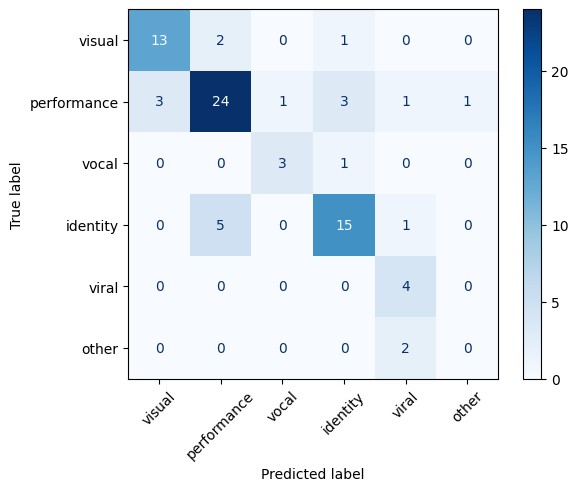

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

labels = ["visual","performance","vocal","identity","viral","other"]

cm = confusion_matrix(
    df3["human_topic"],
    df3["focus_topic"],
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(xticks_rotation=45,cmap="Blues")
plt.show()

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(df3["human_topic"],df3["focus_topic"],digits=3))

              precision    recall  f1-score   support

    identity      0.750     0.714     0.732        21
       other      0.000     0.000     0.000         2
 performance      0.774     0.727     0.750        33
       viral      0.500     1.000     0.667         4
      visual      0.812     0.812     0.812        16
       vocal      0.750     0.750     0.750         4

    accuracy                          0.738        80
   macro avg      0.598     0.667     0.618        80
weighted avg      0.741     0.738     0.735        80



以 focus topic 為分組變數，利用 ANOVA 檢驗各組平均觀看數是否存在顯著差異 ( p-value 0.02713 )，並進一步使用 Tukey HSD 比較各主題間的差異情形，評估留言語意是否具有額外的解釋價值，作為後續擴模依據

In [ ]:
from scipy.stats import f_oneway
groups = []
anova_df = df_llm.dropna(subset=["focus_topic", "log_views"])
for topic in anova_df["focus_topic"].unique():
    groups.append(anova_df.loc[anova_df["focus_topic"] == topic,"log_views"])
f_stat, p_value = f_oneway(*groups)

print("F-statistic:", round(f_stat, 4))
print("p-value:", round(p_value, 6))

F-statistic: 2.5572
p-value: 0.027355


In [ ]:
anova_df["focus_topic"].value_counts()
anova_df.groupby("focus_topic")["views"].agg(["count","mean","std"])

,count,mean,std
focus_topic,,,
identity,99,841732.686869,8.287579e+05
other,12,761617.166667,1.030869e+06
performance,123,578295.609756,4.766105e+05
viral,15,665676.000000,8.099485e+05
visual,82,625203.134146,6.935836e+05
vocal,16,436793.750000,3.680505e+05


In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
tukey_data = df_llm.dropna(subset=["focus_topic", "log_views"])

tukey = pairwise_tukeyhsd(
    endog=tukey_data["log_views"],
    groups=tukey_data["focus_topic"],
    alpha=0.05
)
print(tukey)

     Multiple Comparison of Means - Tukey HSD, FWER=0.05     
   group1      group2   meandiff p-adj   lower  upper  reject
-------------------------------------------------------------
   identity       other  -0.2873 0.8011 -0.9355 0.3609  False
   identity performance  -0.2761 0.0659 -0.5625 0.0102  False
   identity       viral  -0.2413 0.8476 -0.8289 0.3463  False
   identity      visual  -0.3044 0.0675  -0.621 0.0123  False
   identity       vocal  -0.4931  0.135 -1.0645 0.0783  False
      other performance   0.0112    1.0 -0.6302 0.6525  False
      other       viral    0.046    1.0 -0.7753 0.8673  False
      other      visual  -0.0171    1.0 -0.6725 0.6384  False
      other       vocal  -0.2058 0.9783 -1.0157  0.604  False
performance       viral   0.0348    1.0 -0.5451 0.6148  False
performance      visual  -0.0283 0.9998 -0.3306 0.2741  False
performance       vocal   -0.217 0.8798 -0.7806 0.3466  False
      viral      visual  -0.0631 0.9997 -0.6586 0.5324  False
      vi

將 LLM 標註之留言特徵（sentiment_score、focus topic）納入原始舞台特徵模型，重新建立模並透過 K-Fold 正交則化驗證模型穩定性
> 平均 R²：0.329 → 0.4433 (提升約：34.74 %)

In [ ]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import Ridge
import pandas as pd

feature_cols = [
    "line_share",
    "post_week",
    "opening",
    "center_count",
    "ending_take",
    "popularity",
    "song",
    "LLM_sentiment",
    "focus_topic"
]

X_llm_raw = df_llm[feature_cols].copy()
X_llm = pd.get_dummies(X_llm_raw, drop_first=True)

y_llm = df_llm["log_views"]

combined_df = pd.concat([X_llm, y_llm], axis=1)
combined_df = combined_df.dropna()

X_llm_cleaned = combined_df.drop(columns=["log_views"])
y_llm_cleaned = combined_df["log_views"]

model = Ridge(alpha=10)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

llm_scores = cross_val_score(
    model,
    X_llm_cleaned,
    y_llm_cleaned,
    cv=kf,
    scoring="r2"
)

print("=== Base + LLM Model (修正後正確版) ===")
print("各 Fold 的 R² 分數:", llm_scores)
print("平均 R² (Mean R²):", round(llm_scores.mean(), 4))

=== Base + LLM Model (修正後正確版) ===
各 Fold 的 R² 分數: [0.50736895 0.29591474 0.45830605 0.39953753 0.55528058]
平均 R² (Mean R²): 0.4433


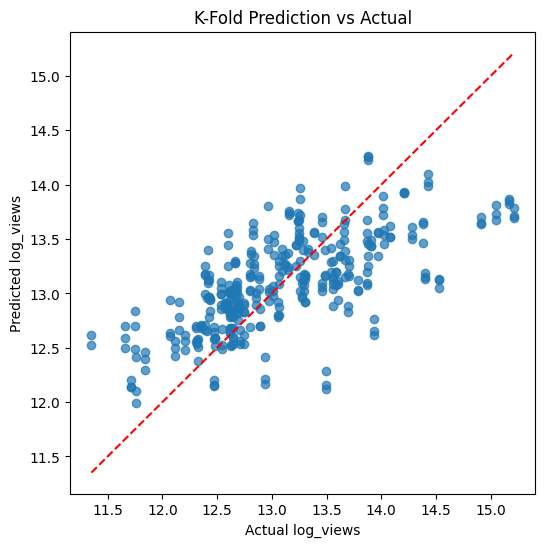

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict

y_pred = cross_val_predict(model, X_llm_cleaned, y_llm_cleaned, cv=kf)
plt.figure(figsize=(6,6))
plt.scatter(y_llm_cleaned,y_pred,alpha=0.7)

plt.plot(
    [y_llm_cleaned.min(), y_llm_cleaned.max()],
    [y_llm_cleaned.min(), y_llm_cleaned.max()],
    color="red",linestyle="--"
)

plt.xlabel("Actual log_views")
plt.ylabel("Predicted log_views")
plt.title("K-Fold Prediction vs Actual")
plt.show()

## 研究結論

完成留言標註流程，並透過人工驗證確認 LLM 標註具有良好一致性。後續分析顯示，留言語意類別可提供舞台特徵以外的補充資訊，證明文本分析具有研究價值

此亦作為後續 RAG Knowledge Base 的核心資料來源，銜接 Retrieval、AI Agent 與自然語言查詢系統的建置